# 🫘 Kidney Disease Dataset — Exploratory Data Analysis (EDA)
**Member 3's notebook**

Goal: Understand the chronic kidney disease (CKD) dataset before building any models.

Run cells one by one and observe the output.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/raw/kidney.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (400, 26)
Columns: ['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [3]:
# Basic info — note many columns have missing values
df.info()
print('\nMissing values (sorted):')
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])
print(f'\nTotal missing: {df.isnull().sum().sum()} out of {df.shape[0] * df.shape[1]} cells')

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    str    
 7   pc              335 non-null    str    
 8   pcc             396 non-null    str    
 9   ba              396 non-null    str    
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    str    
 17  wc              295 non-null    str    
 18  r

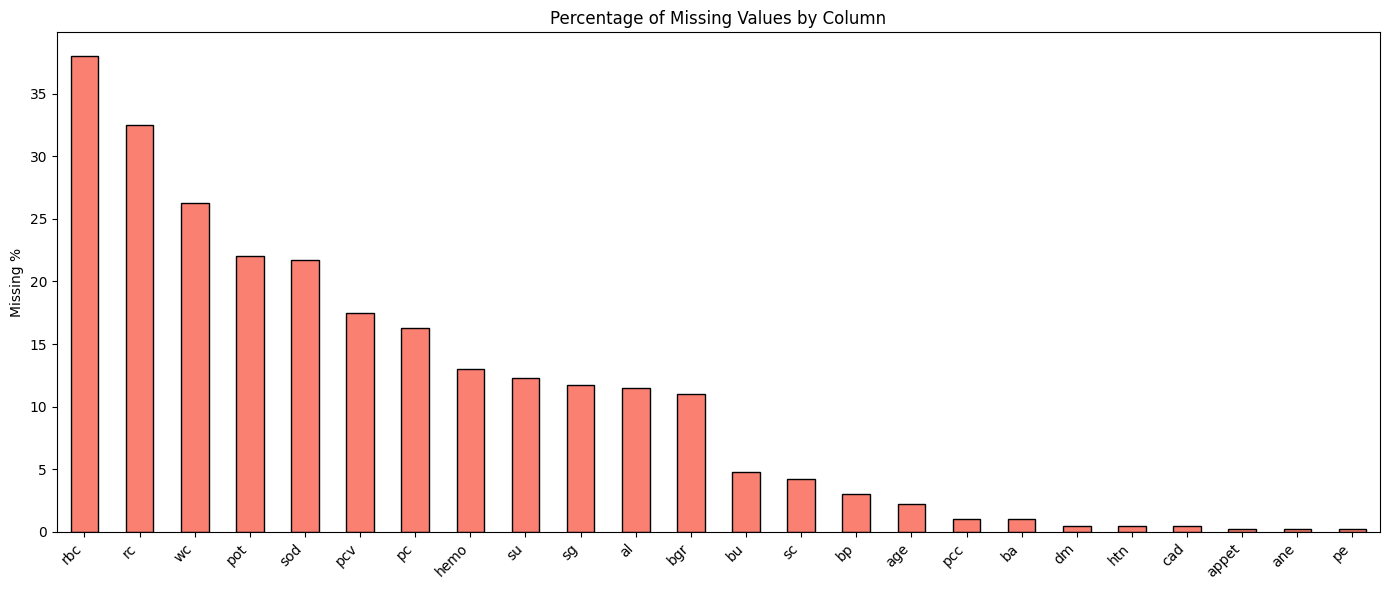

In [4]:
# Visualize missing values
plt.figure(figsize=(14, 6))
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0].plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Percentage of Missing Values by Column')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
# Q: Which columns have the most missing data? How will you handle them?

Target (classification) distribution:
classification
ckd       250
notckd    150
Name: count, dtype: int64


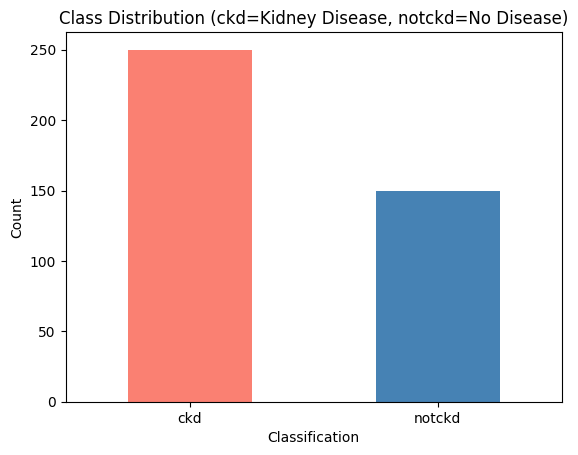

In [5]:
# Target distribution — CKD vs Not CKD
# Clean target column first (may have whitespace/tab issues)
df['classification'] = df['classification'].str.strip()
print('Target (classification) distribution:')
print(df['classification'].value_counts())

df['classification'].value_counts().plot(kind='bar', color=['salmon', 'steelblue'])
plt.title('Class Distribution (ckd=Kidney Disease, notckd=No Disease)')
plt.xlabel('Classification')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()
# Q: Is the dataset balanced? If not, how will you handle it?

In [6]:
# Statistical summary of numeric columns
df.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [7]:
# Identify column types
numeric_cols = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
categorical_cols = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

print(f'Numeric columns ({len(numeric_cols)}): {numeric_cols}')
print(f'Categorical columns ({len(categorical_cols)}): {categorical_cols}')

Numeric columns (14): ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
Categorical columns (10): ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


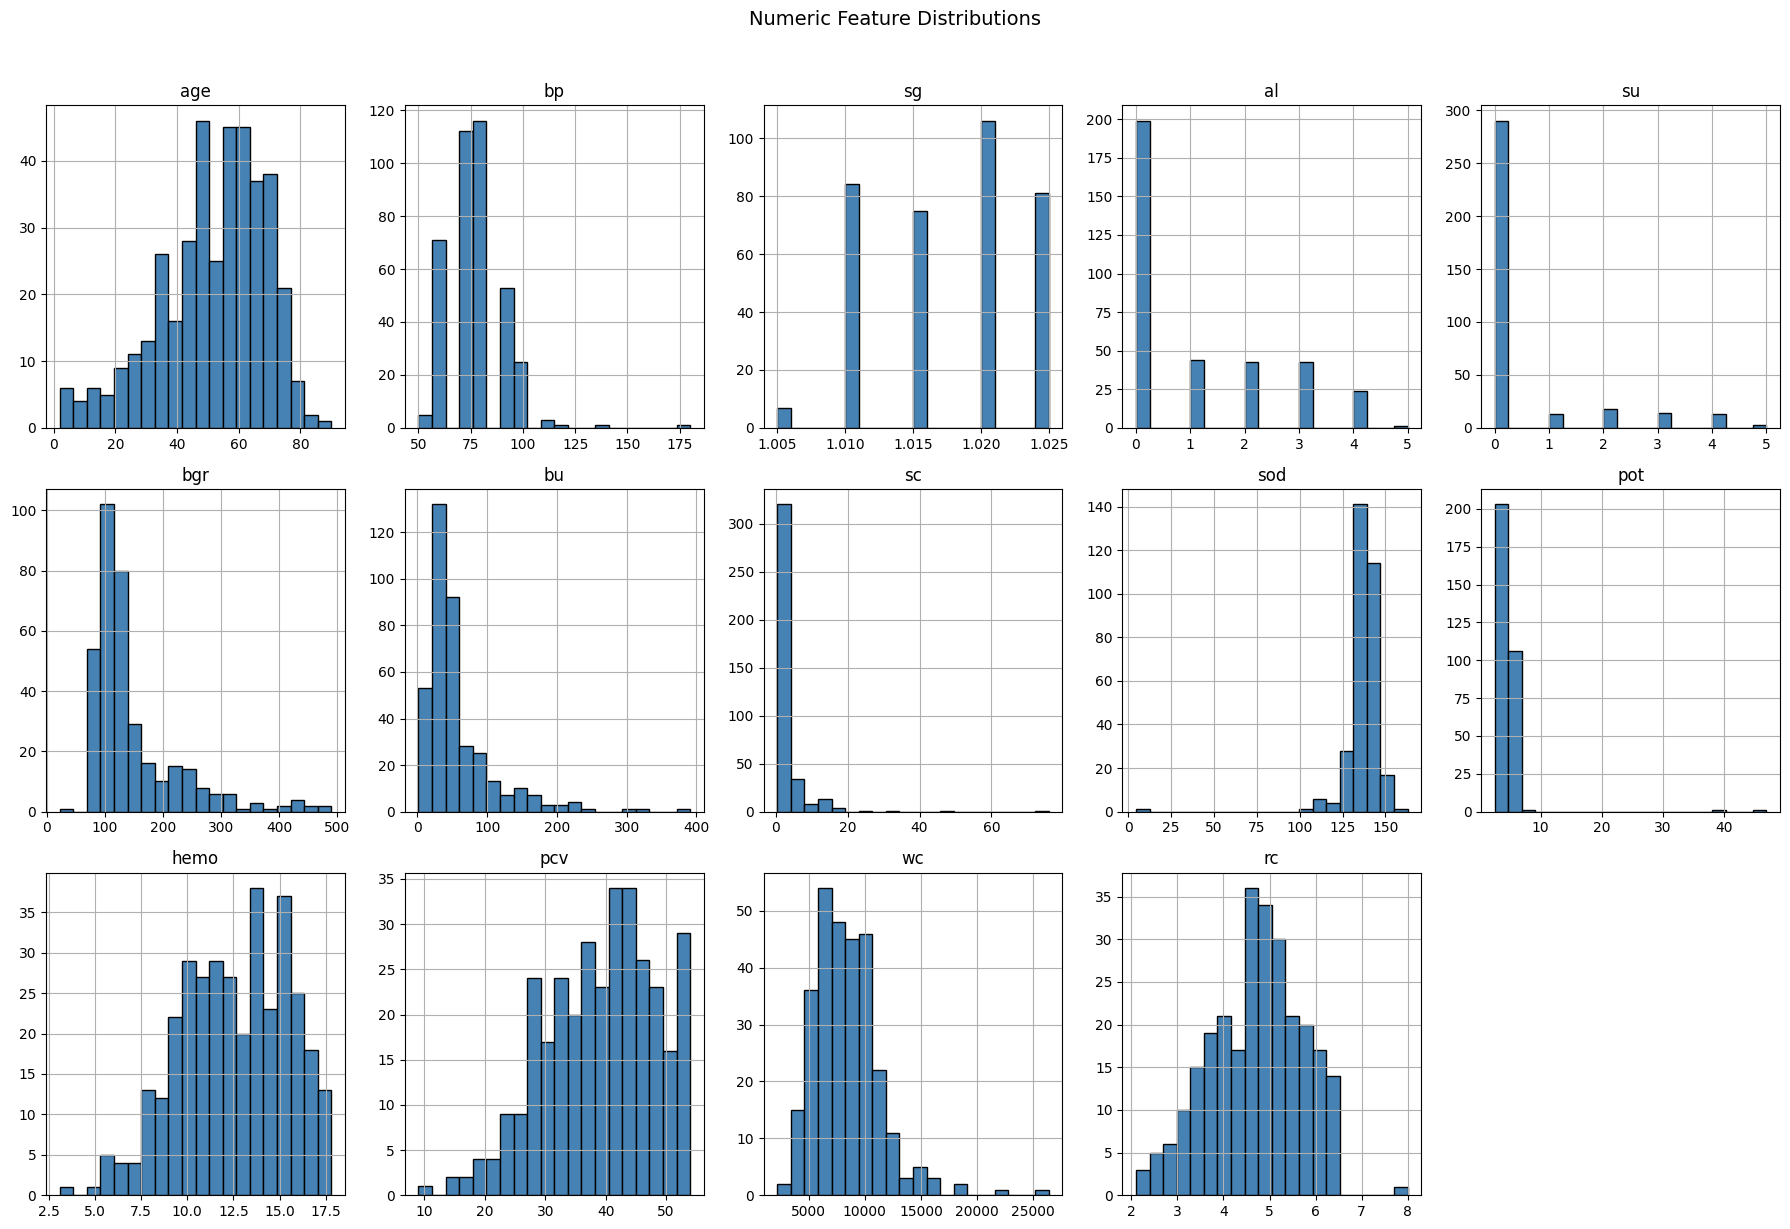

In [8]:
# Distribution of key numeric features
# Convert to numeric first (some may be stored as strings)
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

fig, axes = plt.subplots(3, 5, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    df[col].dropna().hist(bins=20, ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(col)
# Hide extra subplot
axes[14].set_visible(False)
plt.suptitle('Numeric Feature Distributions', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

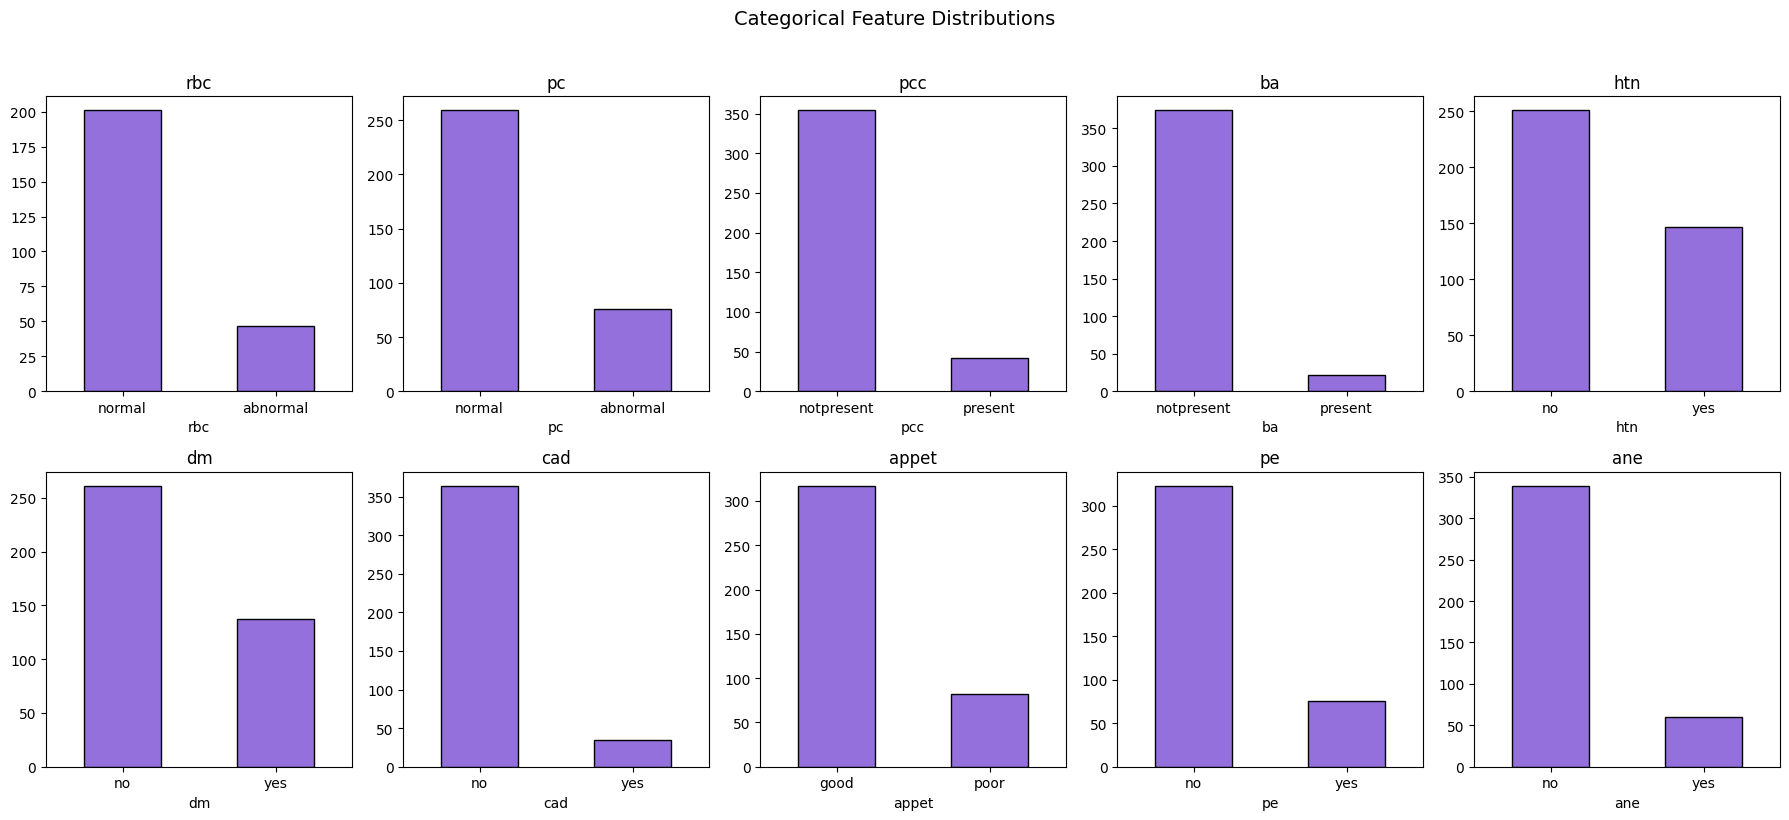

In [9]:
# Categorical feature distributions
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    # Strip whitespace from categorical values
    clean_col = df[col].dropna().astype(str).str.strip()
    clean_col.value_counts().plot(kind='bar', ax=axes[i], color='mediumpurple', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
plt.suptitle('Categorical Feature Distributions', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

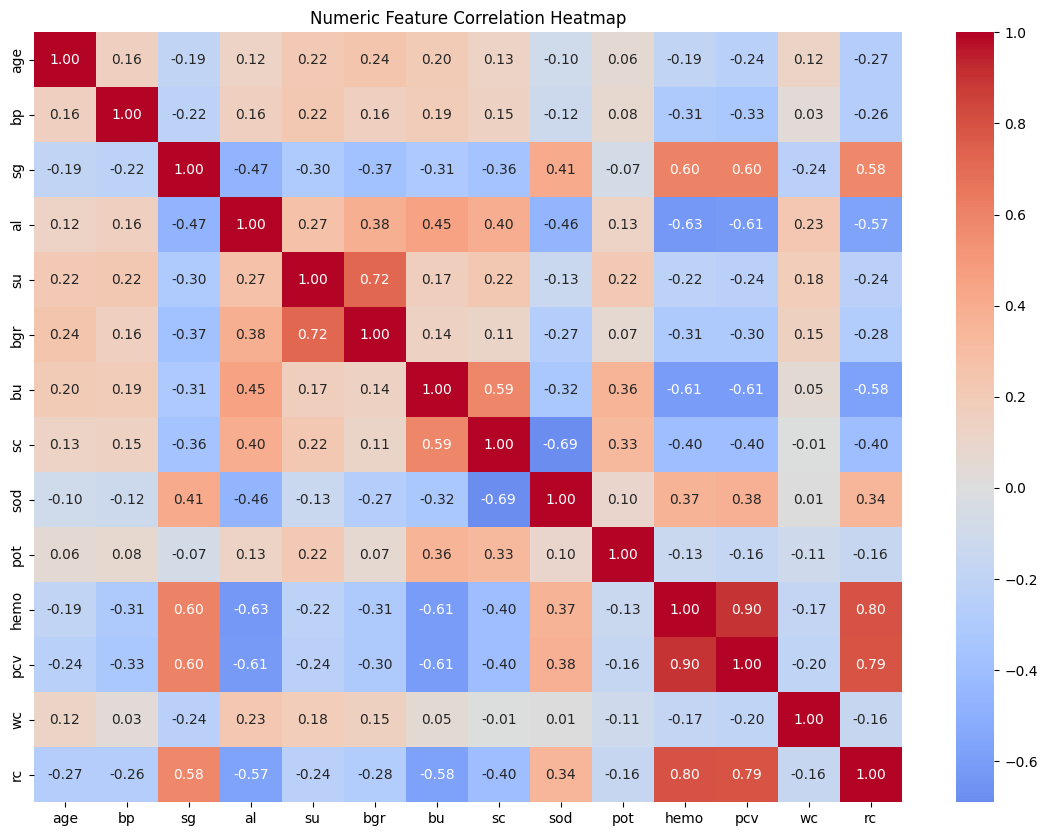

In [10]:
# Correlation heatmap (numeric columns only)
plt.figure(figsize=(14, 10))
corr_df = df[numeric_cols].corr()
sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Numeric Feature Correlation Heatmap')
plt.show()
# Q: Which features are highly correlated with each other?

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_1636\563653017.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([ckd_vals, notckd_vals], labels=['CKD', 'Not CKD'])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_1636\563653017.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([ckd_vals, notckd_vals], labels=['CKD', 'Not CKD'])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_1636\563653017.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([ckd_vals, notckd_vals], labels=['CKD', 'Not CKD'])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_1636\563653017.py:7: MatplotlibDeprecati

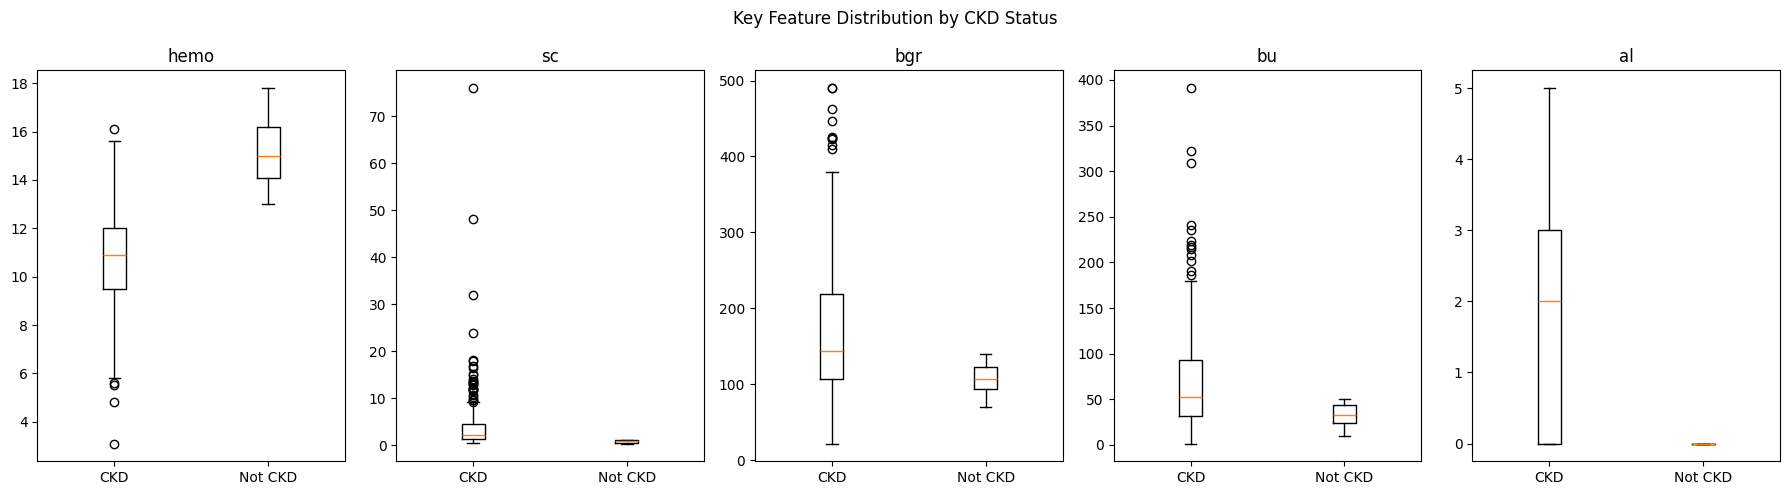

In [11]:
# Box plots — compare key features for CKD vs Not CKD
key_features = ['hemo', 'sc', 'bgr', 'bu', 'al']
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, feat in enumerate(key_features):
    ckd_vals = df[df['classification'] == 'ckd'][feat].dropna()
    notckd_vals = df[df['classification'] == 'notckd'][feat].dropna()
    axes[i].boxplot([ckd_vals, notckd_vals], labels=['CKD', 'Not CKD'])
    axes[i].set_title(feat)
plt.suptitle('Key Feature Distribution by CKD Status')
plt.tight_layout()
plt.show()
# Q: Which features show the clearest separation between CKD and Not CKD?

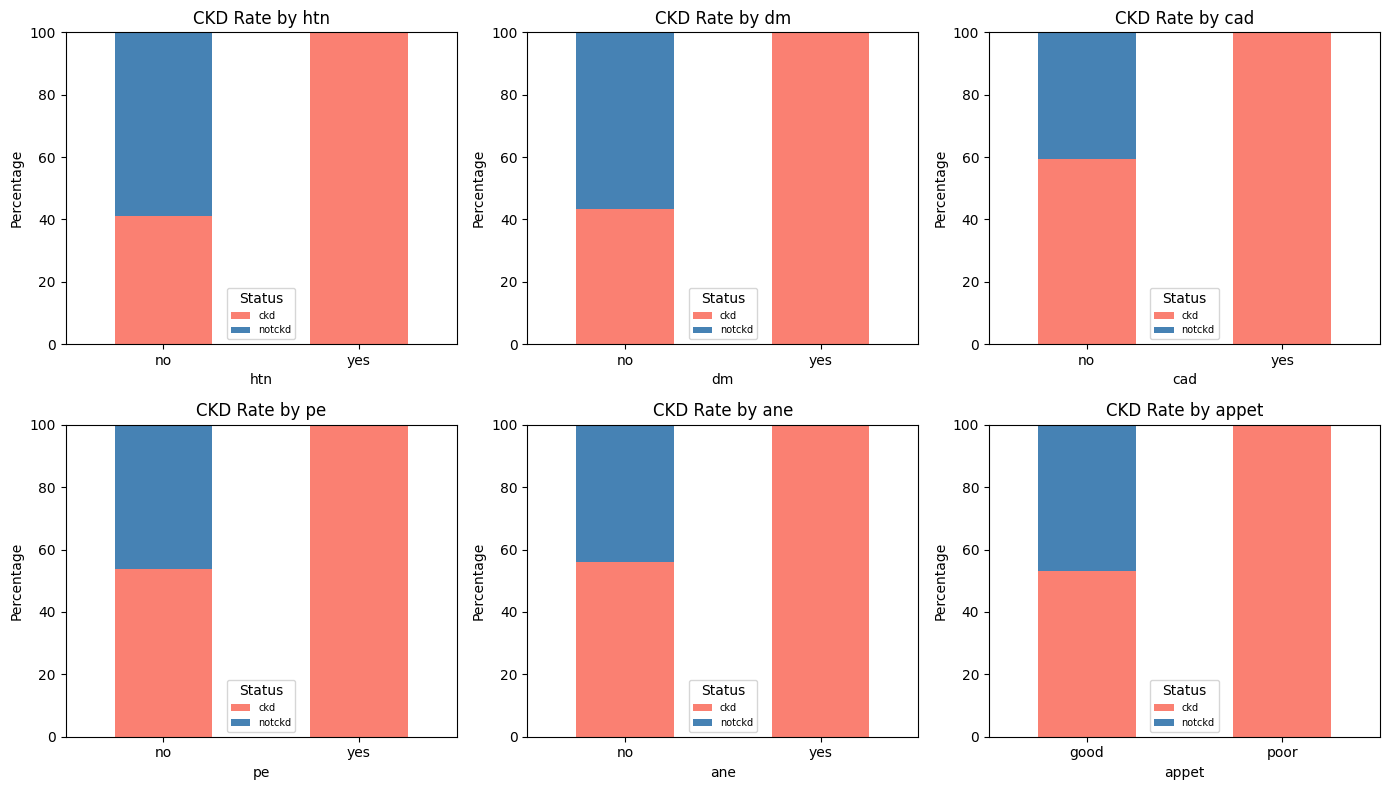

In [12]:
# CKD rate by categorical features
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
key_cats = ['htn', 'dm', 'cad', 'pe', 'ane', 'appet']
for i, col in enumerate(key_cats):
    clean_col = df[col].astype(str).str.strip()
    ct = pd.crosstab(clean_col, df['classification'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['salmon', 'steelblue'])
    axes[i].set_title(f'CKD Rate by {col}')
    axes[i].set_ylabel('Percentage')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
    axes[i].legend(title='Status', fontsize=7)
plt.tight_layout()
plt.show()

## Your Observations
Write your findings here after running the cells above:

- Is the dataset balanced?
- Which columns have the most missing values?
- Which numeric features best separate CKD from Not CKD?
- Which comorbidities (htn, dm, cad) are strongly associated with CKD?
- Any surprising patterns?